In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
print('x_train: ', x_train.shape)

x_train:  (50000, 32, 32, 3)


In [3]:
K = len(np.unique(y_train)) # Classes
Ntr = x_train.shape[0]
Nte = x_test.shape[0]
Din = 3072 # CIFAR10

In [4]:
# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0
mean_image = np.mean(x_train, axis=0)
x_train = x_train - mean_image
x_test = x_test - mean_image

In [5]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=K)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=K)

In [6]:
x_train = np.reshape(x_train,(Ntr,Din))
x_test = np.reshape(x_test,(Nte,Din))
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [7]:
x_train = np.insert(x_train, 0, 1, axis=1)
x_test = np.insert(x_test, 0, 1, axis=1)

In [270]:
std=1e-5
w = std*np.random.randn(Din+1, K) # Din+1 to include bias 

In [271]:
iterations = 300
alpha = 1.4e-2
m = x_train.shape[0]
lamda = 5e-6
decay = 0.95

In [272]:
def cost(x,y,w,lamda):
    m = x.shape[0]
    c = (1/(2*m))*(np.sum(np.square((np.heaviside(np.matmul(x,w),0)-y))) + lamda*np.sum(np.square(w)))
    return c

In [273]:
for i in range(1, iterations+1):
    if i%20 == 0 or i == 1:
        print('Iteration',i,cost(x_train,y_train,w,lamda))
    # forward pass
    h = np.heaviside(np.matmul(x_train,w),0)
    # backward pass
    delta = (1/m)*np.matmul(np.transpose(x_train),(h-y_train)) # delta = 1/m*(X.T)*(X*W-Y)
    w = w*(1-(alpha*lamda/m)) - alpha * delta
    alpha = alpha*decay
print('finished')

Iteration 1 2.5559600000000007
Iteration 20 0.5704500000009869
Iteration 40 0.5225500000008286
Iteration 60 0.5228700000007762
Iteration 80 0.522500000000758
Iteration 100 0.5222500000007516
Iteration 120 0.5222300000007493
Iteration 140 0.5222900000007484
Iteration 160 0.5222900000007482
Iteration 180 0.522270000000748
Iteration 200 0.522260000000748
Iteration 220 0.5222600000007479
Iteration 240 0.5222600000007479
Iteration 260 0.5222600000007479
Iteration 280 0.5222600000007479
Iteration 300 0.5222600000007479
finished


In [285]:
# print train accuracy and loss
scores = np.matmul(x_train,w)
predictions = np.argmax(scores, axis=1)
y_t = np.argmax(y_train,axis=1)
print('Train Accuracy =',np.mean(y_t == predictions),'Test loss =',cost(x_train,y_train,w,lamda))

Train Accuracy = 0.38376 Test loss = 0.522250000000748


In [283]:
# print test accuracy and loss
scores = np.matmul(x_test,w)
predictions = np.argmax(scores, axis=1)
y_t = np.argmax(y_test,axis=1)
print('Test Accuracy =',np.mean(y_t == predictions),'Test loss =',cost(x_test,y_test,w,lamda))

Test Accuracy = 0.3811 Test loss = 0.5155500000037396


In [274]:
w1 = np.transpose(w)

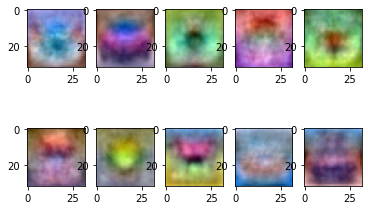

In [282]:
for i in range(K):
    im1 = np.reshape(w1[i][1:],(32,32,3))
    wmin, wmax = np.min(im1), np.max(im1)
    im1 = np.round((255.0 * (im1 - wmin) / (wmax - wmin))).astype('uint8')
    plt.subplot(2,5,i+1),plt.imshow(im1)